In [12]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os

In [13]:
image_path = '../samples/screenshot.png'
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

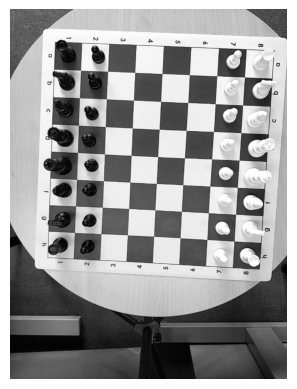

In [14]:
plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()  

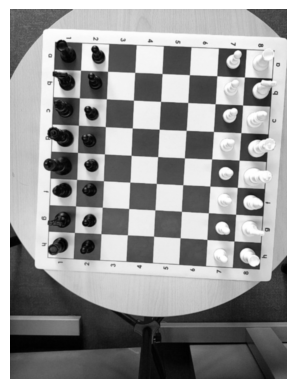

In [15]:
blurred = cv2.GaussianBlur(gray, (3, 3), 0)
plt.imshow(blurred, cmap='gray')
plt.axis('off')
plt.show()

In [16]:
BOARD_SIZE = (7, 7)

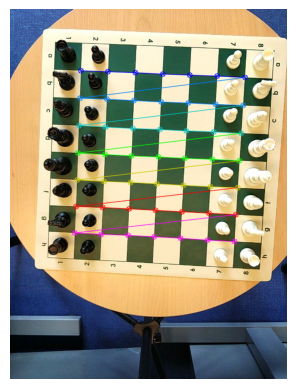

In [17]:
ok, corners = cv2.findChessboardCornersSB(
    gray,
    (7, 7),
    flags=cv2.CALIB_CB_NORMALIZE_IMAGE | cv2.CALIB_CB_EXHAUSTIVE,
)

if ok:
    corners2 = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), 
                                   criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001))
image_with_corners = image.copy()
cv2.drawChessboardCorners(image_with_corners, BOARD_SIZE, corners2, ok)
plt.imshow(image_with_corners)
plt.axis('off')
plt.show()

In [18]:
pts = corners.reshape(BOARD_SIZE[1], BOARD_SIZE[0], 2)

# One-square step vectors estimated from the grid edges.
step_right = (pts[0, -1] - pts[0, 0]) / (BOARD_SIZE[0] - 1)
step_down = (pts[-1, 0] - pts[0, 0]) / (BOARD_SIZE[1] - 1)

tl = pts[0, 0] - step_right - step_down
tr = pts[0, -1] + step_right - step_down
br = pts[-1, -1] + step_right + step_down
bl = pts[-1, 0] - step_right + step_down

board = np.array([tl, tr, br, bl], dtype="float32")

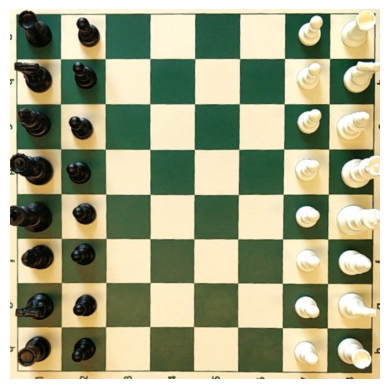

In [19]:
size = 640
p = 10
dst = np.array(
    [[p, p], [size + p - 1, p], [size + p - 1, size + p - 1], [p, size + p - 1]],
    dtype="float32",
)
M = cv2.getPerspectiveTransform(board, dst)
warped = cv2.warpPerspective(image, M, (size + 2 * p, size + 2 * p))
plt.imshow(warped)
plt.axis('off')
plt.show()